# PPO — 1M Steps (Kaggle Version)
**Environment:** `simple_spread_v3` — N=3 agents, discrete actions, max_cycles=50

**Design:** Custom PyTorch (same stack as MAPPO v4) for fair Phase 1 comparison.
- Shared actor policy across all agents
- Per-agent local critic (obs only — no global state)
- Mean team reward, RunningNorm, orthogonal init
- Identical evaluation: 100 greedy episodes, window=100

## Kaggle fixes vs original (Colab) version:
- All save paths → `/kaggle/working/` (no bare filenames)
- Removed torch/numpy/matplotlib from install (already on Kaggle)
- Added GPU check + SAVE_DIR setup cell
- Checkpoint now actually saves `.pth` files into `checkpoint_N/` subfolders
- Added zip + download cell
- Added verify output files cell

In [1]:
# CELL 1 — Install (Kaggle already has torch/numpy/matplotlib)
!pip install -q pettingzoo==1.24.3 gymnasium==0.29.1 supersuit==3.9.3
print("✅ Install complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.8/847.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.6/563.6 kB 31.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
kaggle-environments 1.29.3 requires gymnasium==1.2.0, but you have gymnasium 0.29.1 which is incompatible.
kaggle-environments 1.29.3 requires pettingzoo==1.24.0, but you have pettingzoo 1.24.3 which is incompatible.
shimmy 2.0.1 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
✅ Install 

In [2]:
# CELL 2 — GPU Check + Save Directory
import torch, os
print(f"Torch  : {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device : {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU — go to Settings (right panel) → Accelerator → GPU P100")

# Kaggle output directory — all files saved here persist after session ends
SAVE_DIR = "/kaggle/working"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save dir: {SAVE_DIR}")

Torch  : 2.10.0+cu128
CUDA   : True
Device : Tesla P100-PCIE-16GB
Save dir: /kaggle/working


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [3]:
# CELL 3 — Imports
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import time, os, zipfile, shutil
from pettingzoo.mpe import simple_spread_v3
print("Imports done.")

Imports done.


/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [4]:
# CELL 4 — Environment
env = simple_spread_v3.parallel_env(
    N=3,
    local_ratio=0.5,
    max_cycles=50,
    continuous_actions=False   # discrete: 5 actions per agent
)
obs, _ = env.reset()

AGENTS     = ["agent_0", "agent_1", "agent_2"]
NUM_AGENTS = len(AGENTS)
OBS_DIM    = env.observation_space(env.agents[0]).shape[0]
ACTION_DIM = env.action_space(env.agents[0]).n

print(f"Agents={NUM_AGENTS} | ObsDim={OBS_DIM} | Actions={ACTION_DIM}")

Agents=3 | ObsDim=18 | Actions=5


error: XDG_RUNTIME_DIR not set in the environment.


In [5]:
# CELL 5 — Running Normalizer
class RunningNorm:
    def __init__(self, shape, clip=5.0, eps=1e-8):
        self.mean  = np.zeros(shape, np.float64)
        self.var   = np.ones(shape,  np.float64)
        self.count = eps
        self.clip  = clip
        self.eps   = eps

    def update(self, x):
        x = np.asarray(x, np.float64)
        self.count += 1
        delta       = x - self.mean
        self.mean  += delta / self.count
        self.var   += delta * (x - self.mean)

    @property
    def std(self): return np.sqrt(self.var / self.count + self.eps)

    def normalize(self, x):
        return np.clip((np.asarray(x, np.float64) - self.mean) / self.std,
                       -self.clip, self.clip).astype(np.float32)

obs_norm = RunningNorm(shape=OBS_DIM, clip=5.0)
print("RunningNorm ready.")

RunningNorm ready.


In [6]:
# CELL 6 — Orthogonal Init Helper
def ortho(layer, gain=np.sqrt(2)):
    nn.init.orthogonal_(layer.weight, gain=gain)
    nn.init.zeros_(layer.bias)
    return layer

In [7]:
# CELL 7 — Shared Actor  (256-256, Tanh, LayerNorm)
# Same architecture as MAPPO v4 actor for fair comparison
class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        self.fc1  = ortho(nn.Linear(obs_dim, hidden))
        self.ln1  = nn.LayerNorm(hidden)
        self.fc2  = ortho(nn.Linear(hidden, hidden))
        self.ln2  = nn.LayerNorm(hidden)
        self.head = ortho(nn.Linear(hidden, act_dim), gain=0.01)

    def forward(self, x):
        x = torch.tanh(self.ln1(self.fc1(x)))
        x = torch.tanh(self.ln2(self.fc2(x)))
        return torch.softmax(self.head(x), dim=-1)

In [8]:
# CELL 8 — Local Critic  (256-256, Tanh, LayerNorm)
# PPO key difference from MAPPO: critic sees only local obs,
# NOT the global state — this is what makes it 'independent PPO'
class Critic(nn.Module):
    def __init__(self, obs_dim, hidden=256):
        super().__init__()
        self.fc1  = ortho(nn.Linear(obs_dim, hidden))
        self.ln1  = nn.LayerNorm(hidden)
        self.fc2  = ortho(nn.Linear(hidden, hidden))
        self.ln2  = nn.LayerNorm(hidden)
        self.head = ortho(nn.Linear(hidden, 1), gain=1.0)

    def forward(self, x):
        x = torch.tanh(self.ln1(self.fc1(x)))
        x = torch.tanh(self.ln2(self.fc2(x)))
        return self.head(x)


actor  = Actor(OBS_DIM, ACTION_DIM)
critic = Critic(OBS_DIM)    # local obs only — NOT global state
print(actor)
print(critic)

Actor(
  (fc1): Linear(in_features=18, out_features=256, bias=True)
  (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=256, out_features=5, bias=True)
)
Critic(
  (fc1): Linear(in_features=18, out_features=256, bias=True)
  (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=256, out_features=1, bias=True)
)


In [9]:
# CELL 9 — Hyperparameters  (1M)
TOTAL_STEPS         = 1_000_000

GAMMA               = 0.99
GAE_LAMBDA          = 0.95
CLIP_EPS            = 0.2
PPO_EPOCHS          = 10
MINI_BATCH          = 512
EPISODES_PER_UPDATE = 16

ENTROPY_COEF        = 0.05   # fixed — same as MAPPO v4
VALUE_COEF          = 0.5

ACTOR_LR            = 1e-4
CRITIC_LR           = 3e-4
ACTOR_GRAD_CLIP     = 0.5
CRITIC_GRAD_CLIP    = 0.5

SAVE_EVERY          = 100_000

print("Hyperparameters set — 1M run.")

Hyperparameters set — 1M run.


In [10]:
# CELL 10 — Optimizers & LR Schedulers
actor_opt  = optim.Adam(actor.parameters(),  lr=ACTOR_LR,  eps=1e-5)
critic_opt = optim.Adam(critic.parameters(), lr=CRITIC_LR, eps=1e-5)

timesteps_done = 0

def lr_schedule(t):
    return max(1.0 - t / TOTAL_STEPS, 0.05)

actor_sched  = optim.lr_scheduler.LambdaLR(actor_opt,  lr_lambda=lambda _: lr_schedule(timesteps_done))
critic_sched = optim.lr_scheduler.LambdaLR(critic_opt, lr_lambda=lambda _: lr_schedule(timesteps_done))
print("Optimizers ready.")

Optimizers ready.


In [11]:
# CELL 11 — Rollout Buffer
class Buffer:
    __slots__ = ('obs','actions','logprobs','rewards','dones','values')
    def __init__(self):
        for s in self.__slots__: setattr(self, s, [])
    def clear(self):
        for s in self.__slots__: getattr(self, s).clear()

buf = Buffer()
print("Buffer ready.")

Buffer ready.


In [12]:
# CELL 12 — GAE Computation
def compute_gae(rewards, values, dones):
    adv_list, gae = [], 0.0
    vals = values + [0.0]
    for t in reversed(range(len(rewards))):
        mask  = 1.0 - dones[t]
        delta = rewards[t] + GAMMA * vals[t+1] * mask - vals[t]
        gae   = delta + GAMMA * GAE_LAMBDA * mask * gae
        adv_list.insert(0, gae)
    returns = [a + v for a, v in zip(adv_list, values)]
    return adv_list, returns


def gae_over_buffer():
    all_adv, all_ret = [], []
    ep_start = 0
    for t, d in enumerate(buf.dones):
        if d == 1.0:
            adv, ret = compute_gae(
                buf.rewards[ep_start:t+1],
                buf.values[ep_start:t+1],
                buf.dones[ep_start:t+1]
            )
            all_adv.extend(adv)
            all_ret.extend(ret)
            ep_start = t + 1
    return all_adv, all_ret

In [13]:
# CELL 13 — Action Selection & Value Estimation
# PPO key difference: critic takes local obs, not global state
@torch.no_grad()
def select_actions(obs_dict):
    actions, logprobs = {}, {}
    for ag in AGENTS:
        obs_norm.update(obs_dict[ag])
        x    = torch.FloatTensor(obs_norm.normalize(obs_dict[ag])).unsqueeze(0)
        dist = Categorical(actor(x))
        a    = dist.sample()
        actions[ag]  = a.item()
        logprobs[ag] = dist.log_prob(a).item()
    return actions, logprobs


@torch.no_grad()
def get_value(obs_dict):
    """Average critic value across all agents (local obs only)."""
    vals = []
    for ag in AGENTS:
        x = torch.FloatTensor(obs_norm.normalize(obs_dict[ag])).unsqueeze(0)
        vals.append(critic(x).item())
    return float(np.mean(vals))

In [14]:
# CELL 14 — Reward Normalizer
ret_norm = RunningNorm(shape=1, clip=5.0)

def normalize_reward(r):
    ret_norm.update(np.array([r]))
    std = np.sqrt(ret_norm.var[0] / ret_norm.count + ret_norm.eps)
    return float(np.clip(r / std, -ret_norm.clip, ret_norm.clip))

In [15]:
# CELL 15 — Collect Episodes
def collect(n_eps=EPISODES_PER_UPDATE):
    buf.clear()
    raw_ep_rewards = []

    for _ in range(n_eps):
        obs, _ = env.reset()
        ep_raw = 0.0
        done   = False

        while not done:
            actions, logprbs = select_actions(obs)
            value = get_value(obs)

            next_obs, rewards, terms, truncs, _ = env.step(actions)

            r_mean = float(np.mean(list(rewards.values())))
            ep_raw += r_mean
            r_norm  = normalize_reward(r_mean)

            done = all(terms.values()) or all(truncs.values())

            buf.obs.append(obs)
            buf.actions.append(actions)
            buf.logprobs.append(logprbs)
            buf.rewards.append(r_norm)
            buf.dones.append(float(done))
            buf.values.append(value)

            obs = next_obs

        raw_ep_rewards.append(ep_raw)

    return raw_ep_rewards

In [16]:
# CELL 16 — Build Training Tensors
def build_tensors(advantages, returns):
    obs_l, act_l, lp_l, adv_l = [], [], [], []
    for obs_d, act_d, lp_d, adv in zip(buf.obs, buf.actions, buf.logprobs, advantages):
        for ag in AGENTS:
            obs_l.append(obs_norm.normalize(obs_d[ag]))
            act_l.append(act_d[ag])
            lp_l.append(lp_d[ag])
            adv_l.append(adv)

    obs_t  = torch.FloatTensor(np.stack(obs_l))
    act_t  = torch.LongTensor(act_l)
    lp_t   = torch.FloatTensor(lp_l)
    adv_t  = torch.FloatTensor(adv_l)
    ret_t  = torch.FloatTensor(returns).unsqueeze(1)
    oldv_t = torch.FloatTensor(buf.values).unsqueeze(1)

    return obs_t, act_t, lp_t, adv_t, ret_t, oldv_t

In [17]:
# CELL 17 — Single Mini-Batch Update
def minibatch_update(mb_obs, mb_act, mb_lp, mb_adv, mb_ret):
    mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)

    # ---- Actor ----
    probs   = actor(mb_obs)
    dist    = Categorical(probs)
    new_lp  = dist.log_prob(mb_act)
    entropy = dist.entropy().mean()

    ratio  = torch.exp(new_lp - mb_lp)
    s1     = ratio * mb_adv
    s2     = torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * mb_adv
    a_loss = -torch.min(s1, s2).mean() - ENTROPY_COEF * entropy

    actor_opt.zero_grad()
    a_loss.backward()
    nn.utils.clip_grad_norm_(actor.parameters(), ACTOR_GRAD_CLIP)
    actor_opt.step()

    # ---- Critic (local obs → value) ----
    v_pred = critic(mb_obs)
    c_loss = VALUE_COEF * nn.functional.mse_loss(v_pred, mb_ret)

    critic_opt.zero_grad()
    c_loss.backward()
    nn.utils.clip_grad_norm_(critic.parameters(), CRITIC_GRAD_CLIP)
    critic_opt.step()

    return a_loss.item(), c_loss.item(), entropy.item()

In [18]:
# CELL 18 — PPO Epoch Loop
def ppo_update(tensors):
    obs_t, act_t, lp_t, adv_t, ret_t, oldv_t = tensors
    N = obs_t.shape[0]
    a_losses, c_losses, entropies = [], [], []

    for _ in range(PPO_EPOCHS):
        idx = torch.randperm(N)
        for s in range(0, N, MINI_BATCH):
            i  = idx[s:s + MINI_BATCH]
            ci = i // NUM_AGENTS   # critic index: map agent row → timestep
            al, cl, ent = minibatch_update(
                obs_t[i], act_t[i], lp_t[i],
                adv_t[i].clone(), ret_t[ci]
            )
            a_losses.append(al)
            c_losses.append(cl)
            entropies.append(ent)

    return np.mean(a_losses), np.mean(c_losses), np.mean(entropies)

In [19]:
# CELL 19 — Smoke Test
ep_rs = collect(EPISODES_PER_UPDATE)
adv, ret = gae_over_buffer()
tens = build_tensors(adv, ret)
al, cl, ent = ppo_update(tens)
print(f"Smoke test OK — mean ep: {np.mean(ep_rs):.2f} | "
      f"actor_loss: {al:.4f} | critic_loss: {cl:.4f} | entropy: {ent:.4f}")

Smoke test OK — mean ep: -58.62 | actor_loss: -0.0862 | critic_loss: 1201.9476 | entropy: 1.6074


In [20]:
# CELL 20 — MAIN TRAINING LOOP  (1M steps)
timesteps_done  = 0
best_avg100     = -float('inf')
start_time      = time.time()

all_ep_rewards  = []
a_loss_hist     = []
c_loss_hist     = []
ent_hist        = []
update_n        = 0

print(f"PPO 1M — starting...")
print(f"Total steps: {TOTAL_STEPS:,} | Episodes/update: {EPISODES_PER_UPDATE} | Mini-batch: {MINI_BATCH}")
print("-" * 85)

while timesteps_done < TOTAL_STEPS:

    # ── 1. Collect ──────────────────────────────────────────────────────
    raw_rewards = collect(EPISODES_PER_UPDATE)
    ep_steps    = len(buf.rewards)

    # ── 2. GAE ──────────────────────────────────────────────────────────
    advantages, returns = gae_over_buffer()

    # ── 3. Build tensors ────────────────────────────────────────────────
    tensors = build_tensors(advantages, returns)

    # ── 4. PPO update ───────────────────────────────────────────────────
    al, cl, ent = ppo_update(tensors)
    update_n   += 1

    # ── 5. Step schedulers ──────────────────────────────────────────────
    timesteps_done += ep_steps
    actor_sched.step()
    critic_sched.step()

    # ── 6. Logging ──────────────────────────────────────────────────────
    all_ep_rewards.extend(raw_rewards)
    a_loss_hist.append(al)
    c_loss_hist.append(cl)
    ent_hist.append(ent)

    avg100  = float(np.mean(all_ep_rewards[-100:]))
    ep_mean = float(np.mean(raw_rewards))

    # ── 7. Save best models ─────────────────────────────────────────────
    if avg100 > best_avg100:
        best_avg100 = avg100
        torch.save(actor.state_dict(),  f"{SAVE_DIR}/best_actor.pth")
        torch.save(critic.state_dict(), f"{SAVE_DIR}/best_critic.pth")

    # ── 8. Checkpoint every SAVE_EVERY steps ────────────────────────────
    if timesteps_done % SAVE_EVERY < ep_steps:
        ckpt_dir = f"{SAVE_DIR}/checkpoint_{timesteps_done}"
        os.makedirs(ckpt_dir, exist_ok=True)
        torch.save(actor.state_dict(),  f"{ckpt_dir}/actor.pth")
        torch.save(critic.state_dict(), f"{ckpt_dir}/critic.pth")
        print(f"\n[Checkpoint] {timesteps_done:,} steps | Best Avg100: {best_avg100:.2f}\n")

    # ── 9. Progress every 5 updates ─────────────────────────────────────
    if update_n % 5 == 0:
        elapsed = time.time() - start_time
        eta = (elapsed / max(timesteps_done, 1)) * (TOTAL_STEPS - timesteps_done) / 60
        print(f"Ep {len(all_ep_rewards):5d} | Reward {ep_mean:7.2f} | "
              f"Avg100 {avg100:7.2f} | Steps {timesteps_done:>9,} | "
              f"Ent {ent:.3f} | ALoss {al:.4f} | CLoss {cl:.3f} | "
              f"ETA {eta:.0f}m")

# ── Training complete ─────────────────────────────────────────────────────
total_time = time.time() - start_time
torch.save(actor.state_dict(),  f"{SAVE_DIR}/final_actor.pth")
torch.save(critic.state_dict(), f"{SAVE_DIR}/final_critic.pth")
print(f"\nTraining complete — {total_time/60:.1f} min | Best Avg100: {best_avg100:.2f}")

PPO 1M — starting...
Total steps: 1,000,000 | Episodes/update: 16 | Mini-batch: 512
-------------------------------------------------------------------------------------
Ep    80 | Reward  -51.13 | Avg100  -54.30 | Steps     4,000 | Ent 1.582 | ALoss -0.0847 | CLoss 335.873 | ETA 56m
Ep   160 | Reward  -52.74 | Avg100  -50.18 | Steps     8,000 | Ent 1.544 | ALoss -0.0881 | CLoss 362.514 | ETA 54m
Ep   240 | Reward  -52.40 | Avg100  -49.76 | Steps    12,000 | Ent 1.553 | ALoss -0.0857 | CLoss 377.242 | ETA 55m
Ep   320 | Reward  -48.38 | Avg100  -51.44 | Steps    16,000 | Ent 1.530 | ALoss -0.0848 | CLoss 282.732 | ETA 55m
Ep   400 | Reward  -59.89 | Avg100  -54.96 | Steps    20,000 | Ent 1.531 | ALoss -0.0849 | CLoss 282.404 | ETA 54m
Ep   480 | Reward  -57.57 | Avg100  -56.73 | Steps    24,000 | Ent 1.503 | ALoss -0.0858 | CLoss 237.742 | ETA 54m
Ep   560 | Reward  -55.27 | Avg100  -58.26 | Steps    28,000 | Ent 1.500 | ALoss -0.0876 | CLoss 160.299 | ETA 54m
Ep   640 | Reward  -55.61

In [21]:
# CELL 21 — Final Metrics
print("=" * 50)
print("  PPO — 1M Steps — Final Metrics")
print("=" * 50)
print(f"  Mean Reward   : {np.mean(all_ep_rewards):.2f}")
print(f"  Std  Reward   : {np.std(all_ep_rewards):.2f}")
print(f"  Max  Reward   : {np.max(all_ep_rewards):.2f}")
print(f"  Min  Reward   : {np.min(all_ep_rewards):.2f}")
print(f"  Best Avg100   : {best_avg100:.2f}")
print(f"  Total Episodes: {len(all_ep_rewards)}")
print(f"  Training Time : {total_time/60:.1f} min")
print("=" * 50)

  PPO — 1M Steps — Final Metrics
  Mean Reward   : -44.69
  Std  Reward   : 12.88
  Max  Reward   : -12.55
  Min  Reward   : -169.87
  Best Avg100   : -38.35
  Total Episodes: 20000
  Training Time : 57.1 min


In [22]:
# CELL 22 — Greedy Evaluation (100 episodes)
@torch.no_grad()
def evaluate(n_eps=100):
    actor.load_state_dict(torch.load(f"{SAVE_DIR}/best_actor.pth"))
    actor.eval()
    rewards = []
    for _ in range(n_eps):
        obs, _ = env.reset()
        ep_r, done = 0.0, False
        while not done:
            actions = {}
            for ag in AGENTS:
                x = torch.FloatTensor(
                    obs_norm.normalize(obs[ag])
                ).unsqueeze(0)
                actions[ag] = actor(x).argmax(dim=-1).item()
            obs, rews, terms, truncs, _ = env.step(actions)
            ep_r += float(np.mean(list(rews.values())))
            done  = all(terms.values()) or all(truncs.values())
        rewards.append(ep_r)
    actor.train()
    return rewards


eval_rews = evaluate(100)
print("=" * 50)
print("  Greedy Evaluation — 100 episodes")
print("=" * 50)
print(f"  Mean Reward   : {np.mean(eval_rews):.2f}")
print(f"  Std  Reward   : {np.std(eval_rews):.2f}")
print(f"  Max  Reward   : {np.max(eval_rews):.2f}")
print(f"  Min  Reward   : {np.min(eval_rews):.2f}")
print(f"  Training Time : {total_time/60:.1f} min")
print("=" * 50)

  Greedy Evaluation — 100 episodes
  Mean Reward   : -42.18
  Std  Reward   : 11.44
  Max  Reward   : -17.26
  Min  Reward   : -73.61
  Training Time : 57.1 min


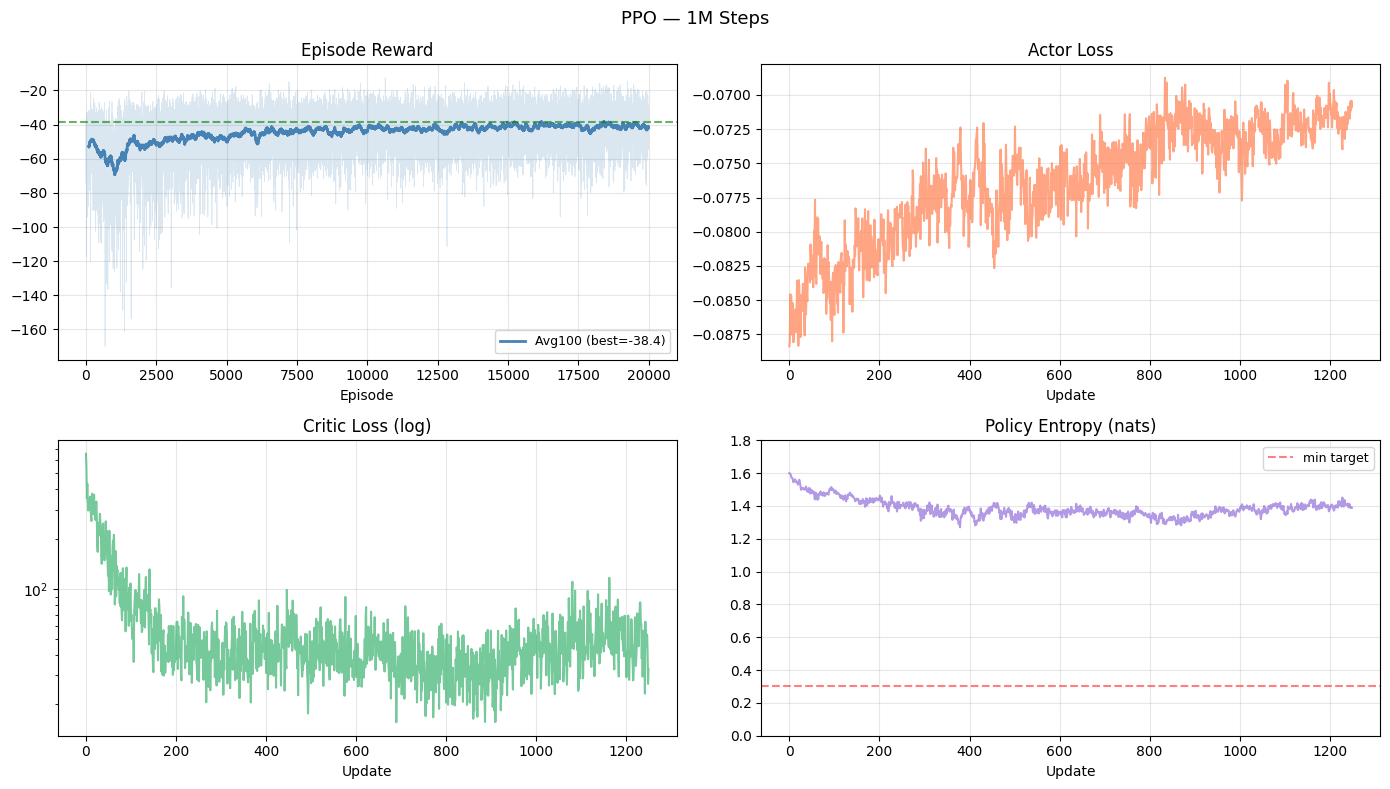

Plot saved → /kaggle/working/ppo_1M_curves.png


In [23]:
# CELL 23 — Training Curves
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("PPO — 1M Steps", fontsize=13)

ax = axes[0, 0]
ax.plot(all_ep_rewards, alpha=0.2, color='steelblue', lw=0.5)
w = 100
if len(all_ep_rewards) >= w:
    ma = np.convolve(all_ep_rewards, np.ones(w)/w, mode='valid')
    ax.plot(range(w-1, len(all_ep_rewards)), ma, color='steelblue', lw=2,
            label=f'Avg100 (best={best_avg100:.1f})')
ax.axhline(best_avg100, color='green', ls='--', alpha=0.6)
ax.set_title("Episode Reward"); ax.set_xlabel("Episode")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(a_loss_hist, color='coral', alpha=0.7)
ax.set_title("Actor Loss"); ax.set_xlabel("Update"); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
cl_arr = np.maximum(np.array(c_loss_hist), 1e-6)
ax.semilogy(cl_arr, color='mediumseagreen', alpha=0.7)
ax.set_title("Critic Loss (log)"); ax.set_xlabel("Update"); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(ent_hist, color='mediumpurple', alpha=0.7)
ax.axhline(0.3, color='red', ls='--', alpha=0.5, label='min target')
ax.set_title("Policy Entropy (nats)"); ax.set_xlabel("Update")
ax.set_ylim(0, 1.8); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/ppo_1M_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved → {SAVE_DIR}/ppo_1M_curves.png")

In [24]:
# CELL 24 — Save results (Kaggle version)
# Collects all .pth / .png files + checkpoint folders into a single zip

results_dir = f"{SAVE_DIR}/PPO_1M_results"
os.makedirs(results_dir, exist_ok=True)

copied = []

# Copy top-level .pth and .png files
for f in sorted(os.listdir(SAVE_DIR)):
    src = os.path.join(SAVE_DIR, f)
    if os.path.isfile(src) and f.endswith(('.pth', '.png')):
        dst = os.path.join(results_dir, f)
        shutil.copy(src, dst)
        size_kb = os.path.getsize(dst) / 1024
        copied.append((f, size_kb))
        print(f"  {f:50s} {size_kb:7.1f} KB")

# Copy checkpoint subfolders
for entry in sorted(os.listdir(SAVE_DIR)):
    src = os.path.join(SAVE_DIR, entry)
    if os.path.isdir(src) and entry.startswith('checkpoint_'):
        dst_sub = os.path.join(results_dir, entry)
        shutil.copytree(src, dst_sub, dirs_exist_ok=True)
        n_pth = len([x for x in os.listdir(dst_sub) if x.endswith('.pth')])
        print(f"  {entry}/  ({n_pth} .pth files)")
        copied.append((entry, 0))

# Zip everything
zip_path = f"{SAVE_DIR}/PPO_1M.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(results_dir):
        for file in files:
            full = os.path.join(root, file)
            arcname = os.path.relpath(full, results_dir)
            zf.write(full, arcname)

zip_size = os.path.getsize(zip_path) / (1024*1024)
print(f"\n{'='*60}")
print(f"  Saved {len(copied)} items → {results_dir}")
print(f"  Zip: PPO_1M.zip ({zip_size:.1f} MB)")
print(f"{'='*60}")
print("\nTo download:")
print("  Kaggle → right panel → Output tab → PPO_1M.zip")
print("  Then upload zip to Google Drive manually")

  best_actor.pth                                       289.0 KB
  best_critic.pth                                      285.0 KB
  final_actor.pth                                      289.0 KB
  final_critic.pth                                     285.0 KB
  ppo_1M_curves.png                                    240.5 KB
  checkpoint_100000/  (2 .pth files)
  checkpoint_1000000/  (2 .pth files)
  checkpoint_200000/  (2 .pth files)
  checkpoint_300000/  (2 .pth files)
  checkpoint_400000/  (2 .pth files)
  checkpoint_500000/  (2 .pth files)
  checkpoint_600000/  (2 .pth files)
  checkpoint_700000/  (2 .pth files)
  checkpoint_800000/  (2 .pth files)
  checkpoint_900000/  (2 .pth files)

  Saved 15 items → /kaggle/working/PPO_1M_results
  Zip: PPO_1M.zip (6.4 MB)

To download:
  Kaggle → right panel → Output tab → PPO_1M.zip
  Then upload zip to Google Drive manually


In [25]:
# CELL 25 — Verify output files (run anytime to check)

print(f"Files in {SAVE_DIR}:")
all_files = []
for f in sorted(os.listdir(SAVE_DIR)):
    full = os.path.join(SAVE_DIR, f)
    if os.path.isfile(full) and f.endswith(('.pth', '.png', '.zip')):
        size = os.path.getsize(full) / 1024
        all_files.append(f)
        print(f"  {f:50s} {size:7.1f} KB")
    elif os.path.isdir(full) and f.startswith('checkpoint_'):
        n = len([x for x in os.listdir(full) if x.endswith('.pth')])
        print(f"  {f}/  ({n} .pth files)")
        all_files.append(f)
print(f"\nTotal items: {len(all_files)}")
print("\nTo download: Kaggle → Output tab (right panel) → click download icon")

Files in /kaggle/working:
  PPO_1M.zip                                          6579.8 KB
  best_actor.pth                                       289.0 KB
  best_critic.pth                                      285.0 KB
  checkpoint_100000/  (2 .pth files)
  checkpoint_1000000/  (2 .pth files)
  checkpoint_200000/  (2 .pth files)
  checkpoint_300000/  (2 .pth files)
  checkpoint_400000/  (2 .pth files)
  checkpoint_500000/  (2 .pth files)
  checkpoint_600000/  (2 .pth files)
  checkpoint_700000/  (2 .pth files)
  checkpoint_800000/  (2 .pth files)
  checkpoint_900000/  (2 .pth files)
  final_actor.pth                                      289.0 KB
  final_critic.pth                                     285.0 KB
  ppo_1M_curves.png                                    240.5 KB

Total items: 16

To download: Kaggle → Output tab (right panel) → click download icon
